# <font color='blue' size = '6'> PROJETO INTEGRADOR | PREVISÃO DE ENCERRAMENTO DE EMPRESAS  </font>
<font color='grey' size = '4'> AUTORES: Caio, Fabiano, Marta, Renata </font>

# <font color='darkblue' size = '5'> SOBRE O PROJETO  </font>
Este projeto tem como foco a aplicação de técnicas de ciência de dados para analisar empresas de diferentes segmentos da economia e serviços na Europa e identificar padrões associados ao encerramento de suas operações.

A partir de dados financeiros e cadastrais de empresas, referentes ao período de 2005 a 2016, foi desenvolvido um pipeline de preparação e análise dos dados, seguido da construção de um modelo preditivo de classificação.

O modelo busca identificar se uma empresa apresenta características associadas à possibilidade de deixar de operar em até dois anos seguintes ao período observado.

# <font color='darkblue' size = '5'> OBJETIVO  </font>
Desenvolver e avaliar um modelo preditivo de classificação capaz de prever, com base nas características disponíveis, se uma empresa poderá deixar de operar em até dois anos.

# <font color='darkblue' size = '5'> PARTE TÉCNICA  </font>
O projeto foi desenvolvido em duas etapas principais. O pré-processamento dos dados foi realizado em Python, resultando em uma base final preparada para a modelagem. A etapa de modelagem preditiva foi realizada em R, utilizando a base final produzida no pré-processamento.

Neste notebook, são apresentados os procedimentos realizados em Python para exploração, tratamento e preparação dos dados.

**IMPORTAÇÃO DAS BIBLIOTECAS**

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
# Importação das bibliotecas utilizadas no projeto
# Pandas: manipulação dos dados
# NumPy: operações numéricas e tratamento de dados
# Matplotlib e Seaborn: visualização dos dados
# Missingno: análise de valores ausentes (missing values) | sugerido no enunciado

**CARREGAMENTO DA BASE DE DADOS**

In [62]:
base = pd.read_csv("cs_bisnode_panel.csv")
# Carregamento da base de dados em um DataFrame chamado "base".

**VISUALIZAÇÃO INICIAL**

In [63]:
base.head()
# Visualização das primeiras linhas para conhecer a estrutura da base.

,comp_id,begin,end,COGS,amort,curr_assets,curr_liab,extra_exp,extra_inc,extra_profit_loss,...,gender,origin,nace_main,ind2,ind,urban_m,region_m,founded_date,exit_date,labor_avg
0,1001034.0,2005-01-01,2005-12-31,NaN,692.592590,7266.666504,7574.074219,0.0,0.0,0.0,...,mix,Domestic,5630.0,56.0,3.0,1,Central,1990-11-19,NaN,NaN
1,1001034.0,2006-01-01,2006-12-31,NaN,603.703674,13122.222656,12211.111328,0.0,0.0,0.0,...,mix,Domestic,5630.0,56.0,3.0,1,Central,1990-11-19,NaN,NaN
2,1001034.0,2007-01-01,2007-12-31,NaN,425.925934,8196.295898,7800.000000,0.0,0.0,0.0,...,mix,Domestic,5630.0,56.0,3.0,1,Central,1990-11-19,NaN,NaN
3,1001034.0,2008-01-01,2008-12-31,NaN,300.000000,8485.185547,7781.481445,0.0,0.0,0.0,...,mix,Domestic,5630.0,56.0,3.0,1,Central,1990-11-19,NaN,NaN
4,1001034.0,2009-01-01,2009-12-31,NaN,207.407410,5137.037109,15300.000000,0.0,0.0,0.0,...,mix,Domestic,5630.0,56.0,3.0,1,Central,1990-11-19,NaN,0.083333


**DIMENSÃO DA BASE DE DADOS**

In [64]:
base.shape
# Verificação da quantidade de linhas e colunas da base.

(287829, 48)

**ESTRUTURA DA BASE DE DADOS**

In [65]:
base.info()
# Verificação da estrutura da base, incluindo tipos das variáveis e quantidade de valores não nulos.

<class 'pandas.DataFrame'>
RangeIndex: 287829 entries, 0 to 287828
Data columns (total 48 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   comp_id               287829 non-null  float64
 1   begin                 287829 non-null  str    
 2   end                   287829 non-null  str    
 3   COGS                  18257 non-null   float64
 4   amort                 279789 non-null  float64
 5   curr_assets           287698 non-null  float64
 6   curr_liab             287698 non-null  float64
 7   extra_exp             269300 non-null  float64
 8   extra_inc             269300 non-null  float64
 9   extra_profit_loss     270626 non-null  float64
 10  finished_prod         17485 non-null   float64
 11  fixed_assets          287698 non-null  float64
 12  inc_bef_tax           280392 non-null  float64
 13  intang_assets         287689 non-null  float64
 14  inventories           287698 non-null  float64
 15  liq_assets 

**LIMPEZA INICIAL DA BASE**


In [66]:
base = base.drop(columns=['COGS', 'finished_prod', 'net_dom_sales',
'net_exp_sales', 'wages', 'D'])
# Remoção das colunas indicadas no enunciado por apresentarem alta proporção de valores ausentes.

**CONFERÊNCIA DA NOVA DIMENSÃO**

In [67]:
base.shape
# Conferência da quantidade de linhas e colunas após a remoção das variáveis.

(287829, 42)

**INVESTIGAÇÃO DE VALORES AUSENTES**

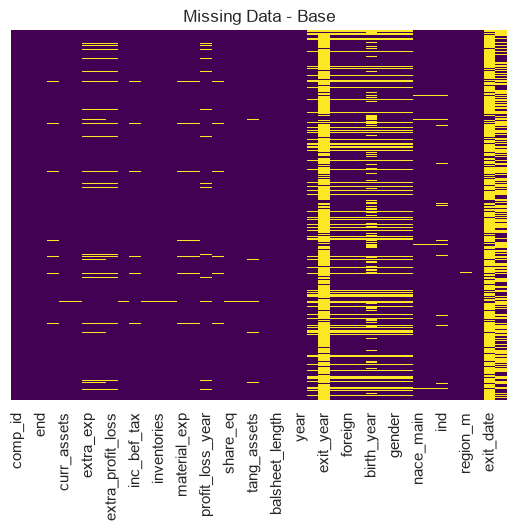

In [68]:
sns.heatmap(base.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title("Missing Data - Base")
plt.show()
# Visualização da presença e concentração de valores ausentes na base.
# O objetivo é identificar as variáveis e regiões da base com maior ocorrência de dados ausentes (missing values).

**VISUALIZAÇÃO DO PADRÃO DE VALORES AUSENTES**

Esta etapa complementa a análise dos valores ausentes, permitindo visualizar seu padrão de ocorrência entre as variáveis da base.

<Axes: >

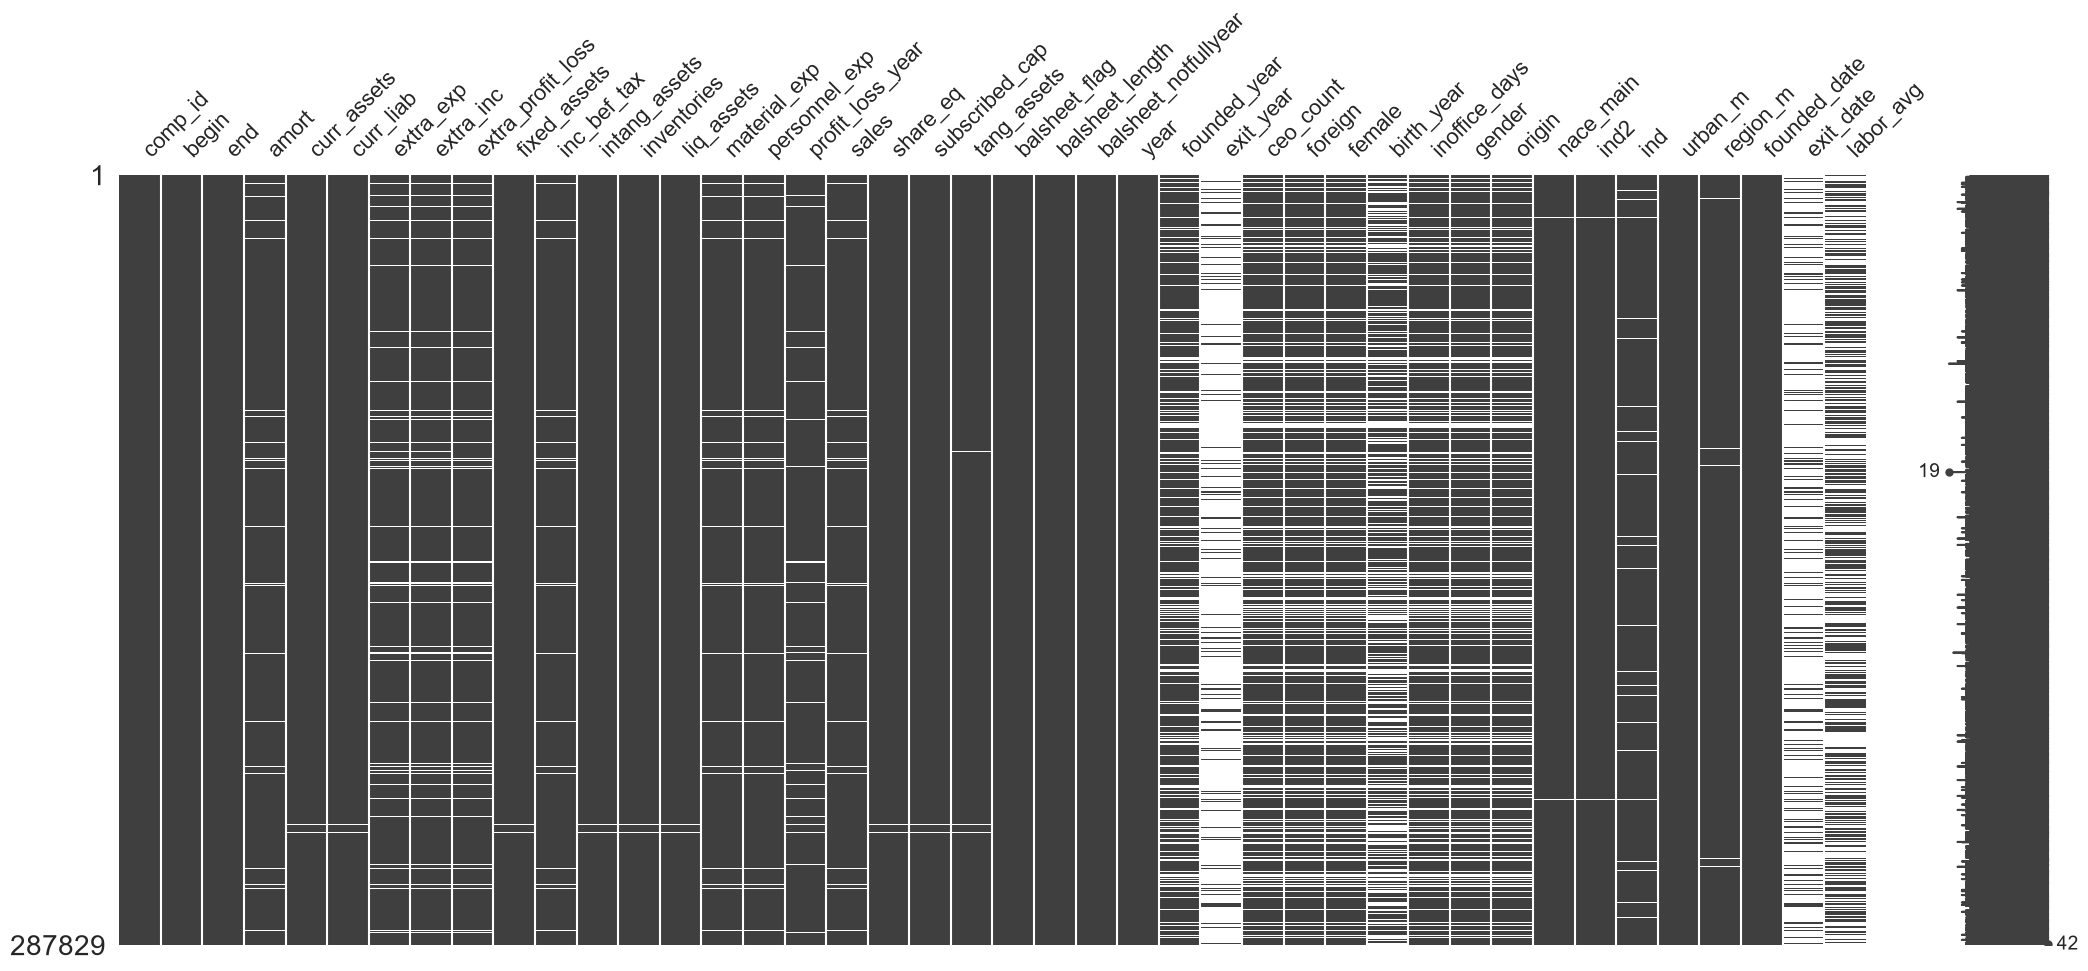

In [69]:
msno.matrix(base)
# Visualização do padrão de valores ausentes utilizando a biblioteca Missingno.
# Auxilia na avaliação da qualidade dos dados.

**CRIAÇÃO DA COLUNA "sales_x_mais_2"**

**Validação de duplicidades por empresa e ano**

A criação de `sales_x_mais_2` pressupõe uma única observação por empresa e ano. Antes de usar `first()`, verificamos se essa condição é satisfeita. Se houver duplicidades, a execução é interrompida para evitar a seleção silenciosa de um registro.

In [70]:
duplicidades_empresa_ano = base.duplicated(
    subset=["comp_id", "year"]
).sum()

print("Duplicidades por empresa e ano:", duplicidades_empresa_ano)

Duplicidades por empresa e ano: 0


**Construção das vendas observadas dois anos à frente**

In [71]:
vendas_por_ano = (base.groupby(["comp_id", "year"])["sales"]
    .first()
    .unstack("year")
)

vendas_futuras = (vendas_por_ano.shift(-2, axis="columns")
    .stack(future_stack=True)
    .rename("sales_x_mais_2")
    .reset_index()
)

base = base.merge(vendas_futuras,
    on=["comp_id", "year"],
    how="left",
    validate="many_to_one"
)

base[["comp_id", "year", "sales", "sales_x_mais_2"]].head()
# Foi criada uma coluna de "sales_x_mais_2", que representa as vendas observadas dois anos à frente para cada empresa e ano
# Essa informação será utilizada posteriormente na definição da variável resposta.

,comp_id,year,sales,sales_x_mais_2
0,1001034.0,2005,62751.851562,65100.000000
1,1001034.0,2006,64625.925781,78085.187500
2,1001034.0,2007,65100.000000,45388.890625
3,1001034.0,2008,78085.187500,9929.629883
4,1001034.0,2009,45388.890625,0.000000


**CRIAÇÃO DA VARIÁVEL "deixou_de_operar"**

In [72]:
ultimo_ano_observado = base["year"].max()
resposta_observavel = base["year"] + 2 <= ultimo_ano_observado

base["deixou_de_operar"] = pd.Series(pd.NA,index=base.index,dtype="Int64"
)

base.loc[resposta_observavel, "deixou_de_operar"] = np.where(
    base.loc[resposta_observavel, "sales_x_mais_2"].isna()
    | (base.loc[resposta_observavel, "sales_x_mais_2"] <= 0),
    1,
    0
)

base["deixou_de_operar"].value_counts(dropna=False)
# A variável "deixou_de_operar" recebe 1 quando não há vendas positivas dois anos à frente, indicando encerramento das operações.
# Quando há vendas positivas dois anos à frente, recebe 0, indicando continuidade das operações.
# Para os anos em que não é possível observar o período de dois anos, a variável permanece como NA.
# Ao final, verificamos a distribuição inicial da variável resposta, observando a quantidade de empresas que deixou de operar e que permaneceu em operação.

deixou_de_operar
0       167876
1        82704
<NA>     37249
Name: count, dtype: Int64

**REMOÇÃO DOS REGISTROS DO ANO DE 2016**

Conforme os requisitos do projeto, os registros referentes ao ano de 2016 foram removidos da base.

In [73]:
base_editada = base.loc[
    base["year"] != 2016
].copy()

In [74]:
base_editada.shape
# Conferência da dimensão da base após a remoção dos registros de 2016.

(278086, 44)

**TRATAMENTO DAS VENDAS NEGATIVAS**

In [75]:
quantidade_sales_negativas = (base_editada["sales"] < 0).sum()
print("Valores negativos antes do tratamento:", quantidade_sales_negativas)

base_editada.loc[:, "sales"] = np.where(
    base_editada["sales"] < 0,
    0,
    base_editada["sales"]
)

print("Valores negativos depois do tratamento:", (base_editada["sales"] < 0).sum())
# Verificação da quantidade de valores negativos na variável "sales".
# Substituição dos valores negativos por 0.
# Verificação da ausência de valores negativos após o tratamento.

Valores negativos antes do tratamento: 38
Valores negativos depois do tratamento: 0


**PREENCHIMENTO DOS VALORES AUSENTES "founded_year"**

In [76]:
base_editada["founded_date"] = pd.to_datetime(
    base_editada["founded_date"],
    errors="coerce"
)

base_editada["founded_year_date"] = base_editada["founded_date"].dt.year

base_editada["founded_year_consolidado"] = (
    base_editada["founded_year"]
    .fillna(base_editada["founded_year_date"])
)

recuperados_por_founded_date = (
    base_editada["founded_year"].isna()
    & base_editada["founded_year_consolidado"].notna()
).sum()

print(
    "Anos recuperados a partir de founded_date:",
    recuperados_por_founded_date
)

base_editada[[
    "comp_id",
    "year",
    "founded_date",
    "founded_year",
    "founded_year_date",
    "founded_year_consolidado"
]].head()
# A coluna "founded_date" está mais completa que "founded_year" e, quando ambas estão preenchidas, os anos coincidem.
# Conversão de "founded_date" para o formato de data.
# O ano é extraído de "founded_date" para preencher os valores ausentes de "founded_year" e gerar a variável "founded_year_consolidado".

Anos recuperados a partir de founded_date: 56127


,comp_id,year,founded_date,founded_year,founded_year_date,founded_year_consolidado
0,1001034.0,2005,1990-11-19,1990.0,1990.0,1990.0
1,1001034.0,2006,1990-11-19,1990.0,1990.0,1990.0
2,1001034.0,2007,1990-11-19,1990.0,1990.0,1990.0
3,1001034.0,2008,1990-11-19,1990.0,1990.0,1990.0
4,1001034.0,2009,1990-11-19,1990.0,1990.0,1990.0


**CÁLCULO DA IDADE DAS EMPRESAS**

In [77]:
base_editada['founded_year_consolidado'].isna().sum()
# Após o preenchimento dos valores ausentes, verificamos a quantidade de valores ainda faltantes na coluna.

np.int64(51)

**Remoção dos registros sem ano de fundação consolidado**

In [78]:
base_editada = base_editada.dropna(
    subset=["founded_year_consolidado"]
).copy()

print(
    "Ausentes restantes em founded_year_consolidado:",
    base_editada["founded_year_consolidado"].isna().sum()
)
# Como restaram apenas 51 registros sem ano de fundação consolidado, optamos por excluir essas observações.

Ausentes restantes em founded_year_consolidado: 0


In [79]:
base_editada["idade_empresa"] = np.where(
    base_editada["founded_year_consolidado"].notna()
    & (base_editada["year"] >= base_editada["founded_year_consolidado"]),
    base_editada["year"] - base_editada["founded_year_consolidado"],
    np.nan
)

base_editada.head()
# Cálculo da idade das empresas a partir das colunas "year" e "founded_year_consolidado".

,comp_id,begin,end,amort,curr_assets,curr_liab,extra_exp,extra_inc,extra_profit_loss,fixed_assets,...,urban_m,region_m,founded_date,exit_date,labor_avg,sales_x_mais_2,deixou_de_operar,founded_year_date,founded_year_consolidado,idade_empresa
0,1001034.0,2005-01-01,2005-12-31,692.592590,7266.666504,7574.074219,0.0,0.0,0.0,1229.629639,...,1,Central,1990-11-19,NaN,NaN,65100.000000,0,1990.0,1990.0,15.0
1,1001034.0,2006-01-01,2006-12-31,603.703674,13122.222656,12211.111328,0.0,0.0,0.0,725.925903,...,1,Central,1990-11-19,NaN,NaN,78085.187500,0,1990.0,1990.0,16.0
2,1001034.0,2007-01-01,2007-12-31,425.925934,8196.295898,7800.000000,0.0,0.0,0.0,1322.222168,...,1,Central,1990-11-19,NaN,NaN,45388.890625,0,1990.0,1990.0,17.0
3,1001034.0,2008-01-01,2008-12-31,300.000000,8485.185547,7781.481445,0.0,0.0,0.0,1022.222229,...,1,Central,1990-11-19,NaN,NaN,9929.629883,0,1990.0,1990.0,18.0
4,1001034.0,2009-01-01,2009-12-31,207.407410,5137.037109,15300.000000,0.0,0.0,0.0,814.814819,...,1,Central,1990-11-19,NaN,0.083333,0.000000,1,1990.0,1990.0,19.0


**FILTRO DA VARIÁVEL "sales" ENTRE €1.000 E €10 MILHÕES**

In [80]:
base_editada = base_editada.loc[
    (base_editada["sales"] > 1_000)
    & (base_editada["sales"] < 10_000_000)
].copy()

base_editada["sales"].describe()
# Filtragem dos registros com valores de "sales" entre €1.000 e €10 milhões.

count    2.182360e+05
mean     2.471549e+05
std      7.860124e+05
min      1.003704e+03
25%      1.639630e+04
50%      4.687407e+04
75%      1.428222e+05
max      9.997007e+06
Name: sales, dtype: float64

**CÁLCULO DO LOG DE "sales"**

In [81]:
base_editada["sales_log"] = np.log1p(base_editada["sales"])
# Transformação logarítmica da variável "sales"

**CRIAÇÃO DA VARIÁVEL PREDITORA "margem"**

In [82]:
base_editada["margem"] = np.where(
    base_editada["sales"] > 0,
    base_editada["profit_loss_year"] / base_editada["sales"],
    np.nan
)

base_editada["margem"].describe()
# Criação da variável "margem", calculada pela razão entre o lucro ou prejuízo do ano e as vendas do mesmo ano.
# A variável poderá ser utilizada como preditora na modelagem.

count    218155.000000
mean         -0.199309
std           6.798467
min       -1154.308930
25%          -0.160425
50%           0.004152
75%           0.044347
max        1289.298755
Name: margem, dtype: float64

**CRIAÇÃO DA VARIÁVEL PREDITORA "venda_por_colaborador"**

In [83]:
base_editada["venda_por_colaborador"] = np.where(
    base_editada["labor_avg"] > 0,
    base_editada["sales"] / base_editada["labor_avg"],
    np.nan
)

base_editada["venda_por_colaborador"].describe()
# Criação da variável "venda_por_colaborador", calculada pela razão entre as vendas e a quantidade média de colaboradores.
# O cálculo é realizado apenas para os registros com informação disponível sobre a quantidade de colaboradores.

count    1.204960e+05
mean     4.382329e+05
std      1.240734e+06
min      8.352733e+02
25%      1.316546e+05
50%      2.334089e+05
75%      4.225809e+05
max      1.180397e+08
Name: venda_por_colaborador, dtype: float64

**Transformação logarítmica de "vendas_por_colaborador**

In [84]:
base_editada["venda_por_colaborador_log"] = np.log1p(
    base_editada["venda_por_colaborador"]
)

base_editada[["venda_por_colaborador",
      "venda_por_colaborador_log"]].describe()
# Transformação logarítmica da variável "venda_por_colaborador" para avaliar sua distribuição.

,venda_por_colaborador,venda_por_colaborador_log
count,1.204960e+05,120496.000000
mean,4.382329e+05,12.360711
std,1.240734e+06,1.050192
min,8.352733e+02,6.728956
25%,1.316546e+05,11.787945
50%,2.334089e+05,12.360551
75%,4.225809e+05,12.954139
max,1.180397e+08,18.586532


**CRIAÇÃO DA VARIÁVEL PREDITORA "liquidez"**

In [85]:
base_editada["liquidez"] = np.where(
    base_editada["curr_liab"] > 0,
    base_editada["curr_assets"] / base_editada["curr_liab"],
    np.nan
)

base_editada["liquidez"].describe()
# Criação da variável "liquidez", calculada pela razão entreos ativos circulantes e os passivos circulantes.
# Esse indicador representa a capacidade da empresa de cobrir obrigações de curto prazo com ativos de curto prazo.
# O filtro garante que o passivo circulante seja positivo, evitando divisão por zero ou por um denominador não positivo.

count    213326.000000
mean          8.916465
std         151.445086
min        -102.500001
25%           0.369880
50%           1.142837
75%           2.873495
max       33519.002903
Name: liquidez, dtype: float64

**CRIAÇÃO DA VARIÁVEL PREDITORA "capital_de_giro"**

In [86]:
base_editada["capital_de_giro"] = base_editada["curr_assets"] - base_editada["curr_liab"]
base_editada["capital_de_giro"].describe()
# Criação da variável "capital_de_giro", calculada pela diferença entre os ativos de curto prazo e as obrigações de curto prazo.
# A variável poderá ser utilizada como preditora na modelagem.

count    2.181620e+05
mean     2.252804e+04
std      2.929331e+06
min     -3.843630e+08
25%     -1.090370e+04
50%      1.222222e+03
75%      1.305926e+04
max      1.228263e+09
Name: capital_de_giro, dtype: float64

**Transformação de "capital_de_giro" com preservação do sinal**

A célula seguinte complementa a transformação ou a conferência descrita na etapa anterior.

In [87]:
base_editada["log_capital_de_giro"] = (np.sign(base_editada["capital_de_giro"])
    * np.log1p(np.abs(base_editada["capital_de_giro"])))

base_editada[["capital_de_giro", "log_capital_de_giro"]
].describe()
# Transformação logarítmica de "capital_de_giro", preservando o sinal dos valores para visualizar melhor a distribuição dos dados.

,capital_de_giro,log_capital_de_giro
count,2.181620e+05,218162.000000
mean,2.252804e+04,1.014798
std,2.929331e+06,9.506172
min,-3.843630e+08,-19.767098
25%,-1.090370e+04,-9.296950
50%,1.222222e+03,7.109244
75%,1.305926e+04,9.477329
max,1.228263e+09,20.928867


**CRIAÇÃO DA VARIÁVEL PREDITORA "porte_empresa"**

In [88]:
base_editada["porte_empresa"] = pd.qcut(
    base_editada['sales'],
    q=4,
    labels=['Pequena', 'Média', 'Grande', 'Muito Grande'])

base_editada["porte_empresa"]
# Criação da variável "porte_empresa" com base no valor de "sales".
# As empresas foram divididas em quatro categorias utilizando os quartis dos valores de vendas, considerando a assimetria da distribuição.
# Cada categoria representa aproximadamente 25% das empresas da amostra.

0               Grande
1               Grande
2               Grande
3               Grande
4                Média
              ...     
287817    Muito Grande
287819         Pequena
287820         Pequena
287821         Pequena
287822         Pequena
Name: porte_empresa, Length: 218236, dtype: category
Categories (4, str): ['Pequena' < 'Média' < 'Grande' < 'Muito Grande']

In [89]:
base_editada['porte_empresa'].value_counts()
# Verificação da quantidade de empresas em cada categoria de porte.

porte_empresa
Pequena         54562
Grande          54559
Muito Grande    54558
Média           54557
Name: count, dtype: int64

In [90]:
pd.crosstab(
    base_editada['porte_empresa'],
    base_editada['deixou_de_operar'],
    normalize='index')
# Relação percentual entre o porte da empresa e a variável resposta, em que 0 indica continuidade das operações e 1 indica encerramento.

deixou_de_operar,0,1
porte_empresa,,
Pequena,0.620777,0.379223
Média,0.721500,0.278500
Grande,0.847504,0.152496
Muito Grande,0.900634,0.099366


In [91]:
base_editada.groupby('porte_empresa')['deixou_de_operar'].mean()
# Cálculo da proporção de empresas que deixaram de operar por porte.

porte_empresa
Pequena         0.379223
Média             0.2785
Grande          0.152496
Muito Grande    0.099366
Name: deixou_de_operar, dtype: Float64

**FILTRO DOS DADOS PARA O ANO DE 2012**

In [92]:
base_2012 = base_editada.loc[
    (base_editada["year"] == 2012)
    & base_editada["deixou_de_operar"].notna()
].copy()

base_2012.loc[:, "situacao"] = base_2012["deixou_de_operar"].map({
    0: "Permaneceu operando",
    1: "Deixou de operar"
})

print("Anos presentes:", base_2012["year"].unique())
print("Respostas ausentes:", base_2012["deixou_de_operar"].isna().sum())

Anos presentes: [2012]
Respostas ausentes: 0


**TRATAMENTO DO ANO DE NASCIMENTO DOS CEOs**

A variável "birth_year" representa o ano de nascimento dos CEOs das empresas. Como foram identificados muitos valores ausentes (missing values) nessa variável, esses casos foram classificados como "Não informado". Em seguida, foi criada uma variável categórica baseada em gerações, com o agrupamento de determinadas categorias na classificação "Outros".

In [93]:
birth_year_valido = (
    pd.to_numeric(base_2012["birth_year"], errors="coerce")
    .replace(0, np.nan)
)

birth_year_valido = birth_year_valido.where(
    birth_year_valido.ge(1900)
    & birth_year_valido.le(base_2012["year"])
)

geracao_original = pd.cut(
    birth_year_valido,
    bins=[
        -np.inf,
        1928,
        1946,
        1965,
        1981,
        1997,
        2013,
        2025,
        np.inf
    ],
    labels=[
        "Anterior à Geração Silenciosa",
        "Geração Silenciosa",
        "Baby Boomers",
        "Geração X",
        "Geração Y (Millennials)",
        "Geração Z",
        "Geração Alfa",
        "Geração Beta"
    ],
    right=False
)


base_2012["geracao_media_ceos"] = (
    geracao_original
    .astype("string")
    .replace({
        "Anterior à Geração Silenciosa": "Outros",
        "Geração Silenciosa": "Outros",
        "Geração Z": "Outros"
    })
    .fillna("Não informado")
    .astype("category")
)
# Anos fora do intervalo considerado válido são classificados como "Não informado".

display(
    base_2012["geracao_media_ceos"]
    .value_counts(dropna=False)
    .rename("quantidade")
)
# Converte temporariamente para texto para permitir reunir categorias distintas.

geracao_media_ceos
Geração X                  8130
Baby Boomers               6693
Não informado              4875
Geração Y (Millennials)    1308
Outros                      708
Name: quantidade, dtype: int64

**TRATAMENTO DAS INFORMAÇÕES DOS CEOss**

As variáveis categóricas "gender" e "origin" são mantidas por serem mais fáceis de interpretar. Os valores ausentes são representados pela categoria "Não informado". As versões numéricas redundantes, "female" e "foreign", serão retiradas da base final.

A variável "inoffice_days" também separada em faixas, dando origem à "faixa_inoffice_days".

Os limites são calculados sem utilizar a variável resposta. Como são definidos a partir da distribuição desta base, devem ser recalculados somente no conjunto de treino caso o projeto adote uma avaliação totalmente isolada entre treino e teste.


In [94]:
for coluna in ["gender", "origin"]:
    base_2012[coluna] = (
        base_2012[coluna]
        .fillna("Não informado")
        .astype("category")
    )
# Valores ausentes das variáveis categóricas são classificados como "Não informado".

faixa_inoffice, limites_inoffice = pd.qcut(
    base_2012["inoffice_days"],
    q=10,
    retbins=True,
    duplicates="drop"
)
# Criação de dez faixas com quantidade semelhante de observações, definidas com base nos quantis da distribuição dos valores observados.

limites_anos = limites_inoffice / 365.25
rotulos_inoffice = [f"Até {limites_anos[1]:.1f} anos"]
# Conversão dos limites das faixas de dias para anos.
# Rótulos em anos tornam as faixas mais fáceis de interpretar.

for indice in range(1, len(limites_anos) - 2):
    rotulos_inoffice.append(
        f"{limites_anos[indice]:.1f} a "
        f"{limites_anos[indice + 1]:.1f} anos"
    )

rotulos_inoffice.append(
    f"Mais de {limites_anos[-2]:.1f} anos"
)

faixa_inoffice = faixa_inoffice.cat.rename_categories(
    rotulos_inoffice
)
# Substituição dos intervalos numéricos pelos rótulos em anos.

base_2012["faixa_inoffice_days"] = (
    faixa_inoffice
    .cat.add_categories(["Não informado"])
    .fillna("Não informado")
)
# Classificação dos valores ausentes como "Não informado".

distribuicao_inoffice = (
    base_2012["faixa_inoffice_days"]
    .value_counts(dropna=False, sort=False)
    .rename("quantidade")
    .to_frame()
)
# Contagem de empresas em cada faixa de tempo no cargo.

distribuicao_inoffice["percentual_base"] = (
    distribuicao_inoffice["quantidade"]
    / len(base_2012)
    * 100
)
# Cálculo do percentual de empresas em cada faixa.

display(distribuicao_inoffice)


,quantidade,percentual_base
faixa_inoffice_days,,
Até 3.3 anos,1971,9.077093
3.3 a 4.7 anos,1973,9.086304
4.7 a 5.5 anos,1976,9.100120
5.5 a 6.2 anos,1964,9.044856
6.2 a 7.1 anos,1979,9.113936
7.1 a 8.2 anos,1966,9.054067
8.2 a 9.3 anos,1969,9.067882
9.3 a 12.0 anos,1968,9.063277
12.0 a 15.6 anos,1972,9.081698


**CONSOLIDAÇÃO DA CLASSIFICAÇÃO SETORIAL**

As colunas "nace_main", "ind2" e "ind" representam diferentes níveis hierárquicos da atividade econômica. A utilização simultânea dessas colunas adicionaria informações sobrepostas aos modelos.

Optamos por manter apenas "ind2", que oferece um nível intermediário de detalhamento: possui menos categorias do que "nace_main" e maior capacidade de diferenciação do que "ind".

Para evitar níveis com poucas observações, as categorias de "ind2" que representam menos de 5% da base de 2012 são reunidas em "Outros".

In [95]:
base_2012["ind2"] = (
    base_2012["ind2"]
    .astype("Int64")
    .astype("string")
)
# Os códigos de "ind2" representam categorias, e não valores numéricos.

frequencia_ind2 = base_2012["ind2"].value_counts(normalize=True)
categorias_raras_ind2 = frequencia_ind2[frequencia_ind2 < 0.05].index

print(
    "Categorias de ind2 agrupadas em Outros:",
    categorias_raras_ind2.tolist()
)
# Identificação das categorias de "ind2" que representam menos de 5% da base de 2012.


base_2012.loc[
    base_2012["ind2"].isin(categorias_raras_ind2),
    "ind2"
] = "Outros"


distribuicao_ind2_final = (
    base_2012["ind2"]
    .value_counts()
    .rename("quantidade")
    .to_frame()
    .assign(
        percentual=lambda tabela: (
            tabela["quantidade"] / len(base_2012) * 100
        )
    )
)
# Conferência da distribuição após o agrupamento.

display(distribuicao_ind2_final)

if (distribuicao_ind2_final["percentual"] < 5).any():
    raise ValueError(
        "Ainda existem categorias de ind2 com menos de 5% da base."
    )
# Validação de que não restaram categorias com menos de 5% da base.

Categorias de ind2 agrupadas em Outros: ['26', '27', '29', '30', '32', '47', '68', '46', '43', '25', '95', '62', '41', '70', '71', '96', '66', '45', '82', '86', '74', '81', '73', '93', '69', '16', '77', '85', '49', '92', '1', '79', '72', '90', '22', '42', '11', '31', '18', '10', '87', '63', '2', '78', '23', '80', '14', '52', '58', '61', '59', '84', '15', '37', '17', '36']


,quantidade,percentual
ind2,,
56,12707,58.519849
Outros,2843,13.092935
55,2264,10.426453
28,1951,8.984987
33,1944,8.952749


**ESTATÍSTICAS DESCRITIVAS DA BASE DE 2012**

In [96]:
base_2012.describe()
# Estatísticas descritivas das variáveis numéricas da base de 2012.

,comp_id,amort,curr_assets,curr_liab,extra_exp,extra_inc,extra_profit_loss,fixed_assets,inc_bef_tax,intang_assets,...,founded_year_date,founded_year_consolidado,idade_empresa,sales_log,margem,venda_por_colaborador,venda_por_colaborador_log,liquidez,capital_de_giro,log_capital_de_giro
count,2.171400e+04,2.167400e+04,2.170400e+04,2.170400e+04,2.171400e+04,2.171400e+04,2.171400e+04,2.170400e+04,2.171400e+04,2.170400e+04,...,21714.000000,21714.000000,21680.000000,21714.000000,21704.000000,1.856400e+04,18564.000000,21308.000000,2.170400e+04,21704.000000
mean,1.536004e+11,9.058334e+03,9.993014e+04,8.727555e+04,1.223491e+03,2.396820e+03,1.170106e+03,1.488680e+05,5.793288e+03,3.883459e+03,...,2003.301372,2003.301372,8.714760,10.712301,-0.216827,4.057504e+05,12.254689,10.514527,1.265459e+04,0.459209
min,1.001541e+06,-1.489630e+04,-3.460000e+04,-8.759259e+03,-1.418519e+03,-1.740741e+02,-2.888889e+05,0.000000e+00,-1.091879e+07,-2.962963e+01,...,1949.000000,1949.000000,0.000000,6.912448,-136.853061,9.015873e+02,6.805265,-57.333337,-2.751152e+07,-17.130116
25%,2.888255e+10,1.148148e+02,3.251852e+03,3.569444e+03,0.000000e+00,0.000000e+00,0.000000e+00,6.666666e+01,-6.344444e+03,0.000000e+00,...,1997.000000,1997.000000,2.000000,9.571510,-0.245341,1.152333e+05,11.654723,0.304697,-1.283333e+04,-9.459879
50%,1.143054e+11,8.555555e+02,1.120926e+04,1.411852e+04,0.000000e+00,0.000000e+00,0.000000e+00,4.311111e+03,2.222222e+02,0.000000e+00,...,2005.000000,2005.000000,7.000000,10.640099,0.000504,2.130955e+05,12.269500,1.062058,6.111111e+02,6.416914
75%,2.579960e+11,3.892593e+03,3.901482e+04,4.665463e+04,0.000000e+00,0.000000e+00,0.000000e+00,3.720555e+04,3.928704e+03,0.000000e+00,...,2010.000000,2010.000000,15.000000,11.776657,0.038671,3.963254e+05,12.889993,2.672930,1.139722e+04,9.341213
max,4.641050e+11,3.570863e+06,2.066350e+07,4.186429e+07,1.704172e+07,1.709232e+07,3.253704e+06,1.036673e+08,4.378226e+06,5.630704e+06,...,2016.000000,2016.000000,63.000000,16.117026,752.109993,5.329769e+07,17.791404,33519.002903,1.154494e+07,16.261758
std,1.380914e+11,4.922297e+04,4.611644e+05,5.111388e+05,1.158939e+05,1.201781e+05,3.093271e+04,1.159659e+06,1.267768e+05,6.678058e+04,...,7.022573,7.022573,7.016143,1.710003,5.478130,9.914693e+05,1.091572,273.300707,3.985721e+05,9.540969


**ESTRUTURA DA BASE DE 2012**

In [97]:
base_2012.info()
# Verificação da estrutura da base, incluindo tipos das variáveis e quantidade de valores não nulos.

<class 'pandas.DataFrame'>
Index: 21714 entries, 14 to 287814
Data columns (total 58 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   comp_id                    21714 non-null  float64       
 1   begin                      21714 non-null  str           
 2   end                        21714 non-null  str           
 3   amort                      21674 non-null  float64       
 4   curr_assets                21704 non-null  float64       
 5   curr_liab                  21704 non-null  float64       
 6   extra_exp                  21714 non-null  float64       
 7   extra_inc                  21714 non-null  float64       
 8   extra_profit_loss          21714 non-null  float64       
 9   fixed_assets               21704 non-null  float64       
 10  inc_bef_tax                21714 non-null  float64       
 11  intang_assets              21704 non-null  float64       
 12  inventories       

**DISTRIBUIÇÃO DA VARIÁVEL RESPOSTA**

In [98]:
base_2012["situacao"].value_counts().sort_index()
# Verificação da quantidade de empresas que deixaram de operar e que permaneceram em operação.

situacao
Deixou de operar        4464
Permaneceu operando    17250
Name: count, dtype: int64

**GRÁFICOS**

In [99]:
sns.set_theme(
    style="whitegrid",
    context="notebook",
    palette="colorblind"
)
# Configuração visual geral dos gráficos.

cores_situacao = {
    "Permaneceu operando": "#2A9D8F",
    "Deixou de operar": "#E76F51"
}
# Cores fixas para a situação da empresa.

**DISTRIBUIÇÃO DAS VENDAS**

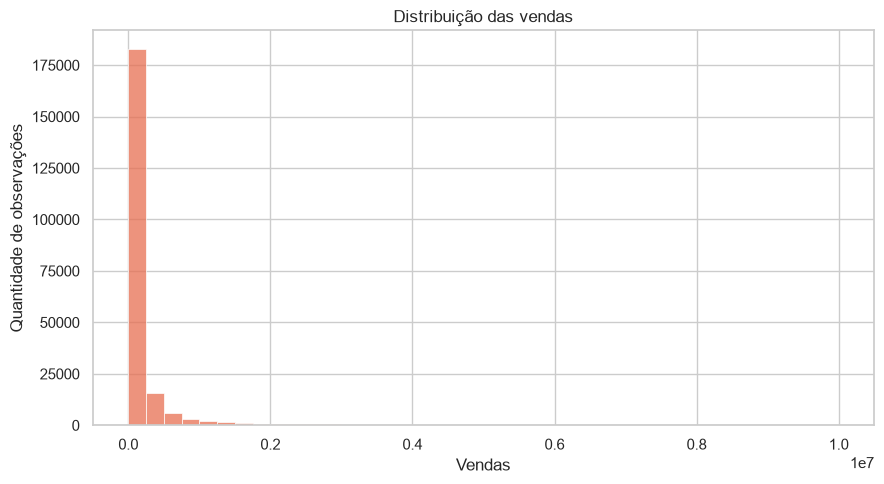

In [100]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=base_editada,
    x="sales",
    bins=40,
    color="#E76F51",
    edgecolor="white",
    linewidth=0.5
)

plt.title("Distribuição das vendas")
plt.xlabel("Vendas")
plt.ylabel("Quantidade de observações")
plt.tight_layout()
plt.show()
# Visualização da distribuição dos valores de vendas na base.

**DISTRIBUIÇÃO DAS VENDAS APÓS A TRANSFORMAÇÃO LOGARÍTMICA**

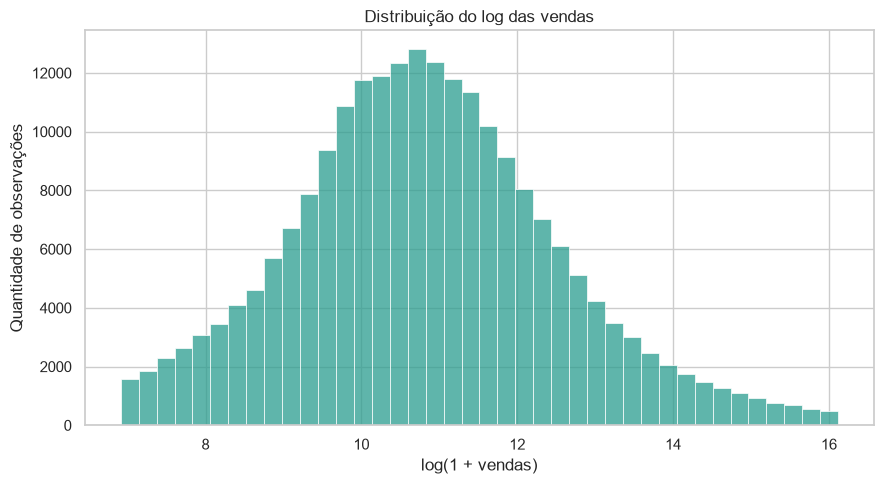

In [101]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=base_editada,
    x="sales_log",
    bins=40,
    color="#2A9D8F",
    edgecolor="white",
    linewidth=0.5
)

plt.title("Distribuição do log das vendas")
plt.xlabel("log(1 + vendas)")
plt.ylabel("Quantidade de observações")
plt.tight_layout()
plt.show()
# Visualização da distribuição da variável "sales_log" após a transformação logarítmica.

**DISTRIBUIÇÃO DAS VENDAS POR COLABORADOR APÓS A TRANSFORMAÇÃO LOGARÍTMICA**

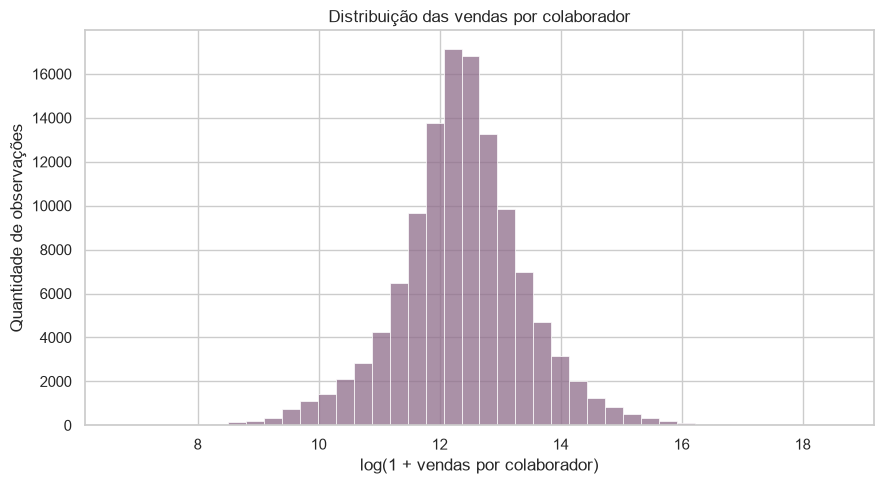

In [102]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=base_editada,
    x="venda_por_colaborador_log",
    bins=40,
    color="#8E6C8A",
    edgecolor="white",
    linewidth=0.5
)

plt.title("Distribuição das vendas por colaborador")
plt.xlabel("log(1 + vendas por colaborador)")
plt.ylabel("Quantidade de observações")
plt.tight_layout()
plt.show()
# Visualização da distribuição da variável "venda_por_colaborador_log" após a transformação logarítmica.

**DISTRIBUIÇÃO DO CAPITAL DE GIRO APÓS A TRANSFORMAÇÃO LOGARÍTMICA**

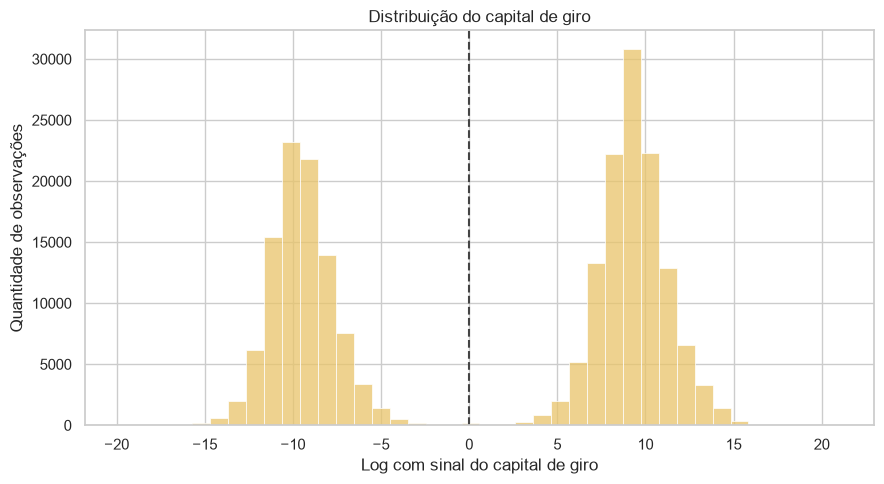

In [103]:
plt.figure(figsize=(9, 5))

sns.histplot(
    data=base_editada,
    x="log_capital_de_giro",
    bins=40,
    color="#E9C46A",
    edgecolor="white",
    linewidth=0.5
)

plt.axvline(
    x=0,
    color="#444444",
    linestyle="--",
    linewidth=1.5
)

plt.title("Distribuição do capital de giro")
plt.xlabel("Log com sinal do capital de giro")
plt.ylabel("Quantidade de observações")
plt.tight_layout()
plt.show()
# Visualização da distribuição da variável "log_capital_de_giro" após a transformação logarítmica com preservação do sinal.

**DISTRIBUIÇÃO DO CAPITAL DE GIRO POR SITUAÇÃO DA EMPRESA — 2012**

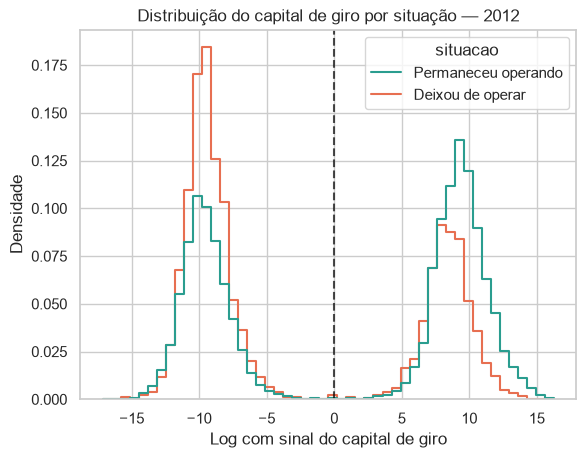

In [104]:
sns.histplot(
    data=base_2012, x="log_capital_de_giro",
    hue="situacao", stat="density", common_norm=False, element="step",
    fill=False, palette =cores_situacao, bins=50)

plt.axvline(0,color="black",
    linestyle="--", alpha=0.7)

plt.title("Distribuição do capital de giro por situação — 2012")
plt.xlabel("Log com sinal do capital de giro")
plt.ylabel("Densidade")
plt.show();
# Comparação da distribuição do capital de giro, em escala logarítmica com preservação do sinal, 
# entre empresas que permaneceram operando e as que deixaram de operar em 2012.

Como cada grupo foi normalizado separadamente, o histograma permite comparar o formato das distribuições apesar do desbalanceamento da resposta. As empresas que permaneceram operando apresentam maior concentração proporcional na região de capital de giro positivo.

Entre as empresas que deixaram de operar, a distribuição apresenta maior concentração proporcional na região de capital de giro negativo. Isso indica associação exploratória, mas não uma relação determinística.

**BOXPLOT DO CAPITAL DE GIRO POR SITUAÇÃO DA EMPRESA — 2012**

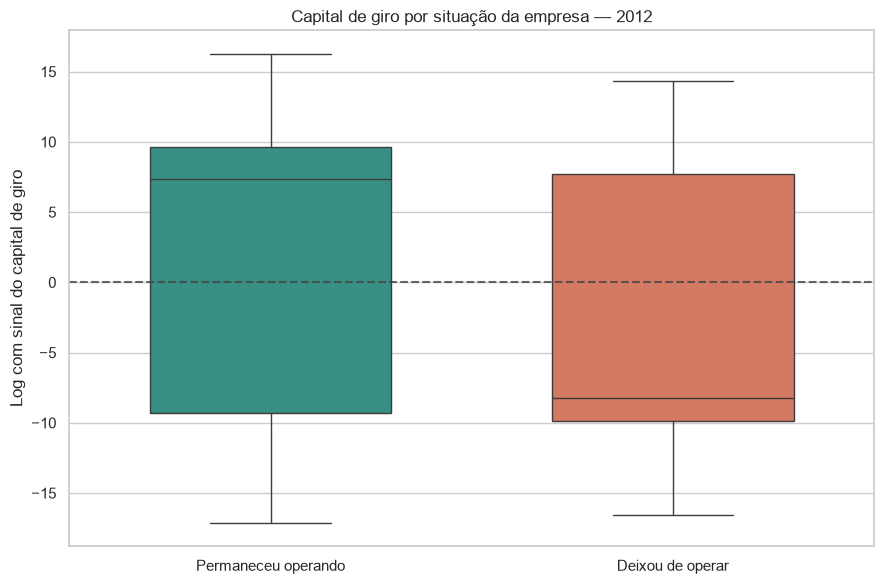

In [105]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=base_2012,
    x="situacao",
    y="log_capital_de_giro",
    hue="situacao",
    palette=cores_situacao,
    legend=False,
    showfliers=False,
    width=0.6
)

plt.axhline(
    y=0,
    color="#444444",
    linestyle="--",
    linewidth=1.5,
    alpha=0.8
)

plt.title("Capital de giro por situação da empresa — 2012")
plt.xlabel("")
plt.ylabel("Log com sinal do capital de giro")
plt.tight_layout()
plt.show()
# Comparação da distribuição de "log_capital_de_giro" entre empresas que permaneceram operando e empresas que deixaram de operar em 2012.

A mediana do capital de giro das empresas que deixaram de operar é negativa, enquanto a mediana das empresas que permaneceram operando é positiva. As caixas ainda apresentam grande sobreposição, portanto o capital de giro não determina isoladamente o encerramento.

Isso não significa que a variável é determinante, pois houve empresas que deixaram de operar mesmo apresentando capital de giro positivo, assim como empresas com capital de giro negativo que continuaram operando.

**BOXPLOT DAS VENDAS POR SITUAÇÃO DA EMPRESA — 2012**

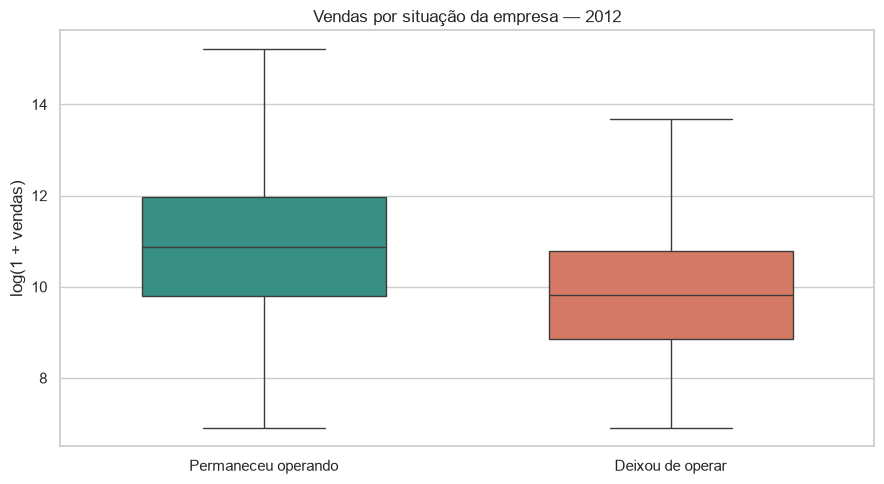

In [106]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=base_2012,
    x="situacao",
    y="sales_log",
    hue="situacao",
    palette=cores_situacao,
    legend=False,
    showfliers=False,
    width=0.6
)

plt.title("Vendas por situação da empresa — 2012")
plt.xlabel("")
plt.ylabel("log(1 + vendas)")
plt.tight_layout()
plt.show()
# Comparação da distribuição de "sales_log" entre empresas que permaneceram operando e empresas que deixaram de operar em 2012.

Neste boxplot, comparamos a distribuição das vendas entre empresas que permaneceram operando e empresas que deixaram de operar, buscando verificar se empresas com menor volume de vendas apresentavam maior concentração no grupo que deixou de operar.

Observa-se que, entre as empresas que deixaram de operar, há maior concentração de valores de vendas mais baixos em comparação com o grupo que permaneceu operando. Esse resultado sugere uma associação entre o volume de vendas e a situação da empresa, mas não permite, isoladamente, concluir que vendas menores determinam o encerramento das operações.

**TAXA DE ENCERRAMENTO POR FAIXA DE IDADE DAS EMPRESAS**

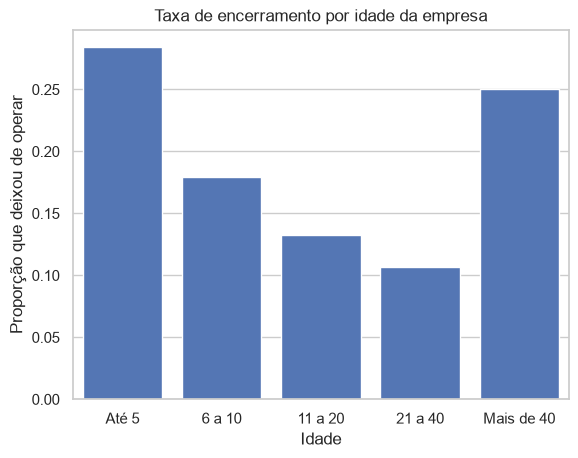

In [107]:
base_2012["faixa_idade"] = pd.cut(
    base_2012["idade_empresa"],
    bins=[0, 5, 10, 20, 40, np.inf],
    labels=["Até 5", "6 a 10", "11 a 20",
        "21 a 40", "Mais de 40" ],
    include_lowest=True)

taxa_idade = ( base_2012
    .groupby("faixa_idade", observed=True)
    .agg( quantidade=("deixou_de_operar", "size"),
        taxa_encerramento=("deixou_de_operar", "mean"))
    .reset_index())

sns.barplot( data=taxa_idade,
    x="faixa_idade",
    y="taxa_encerramento",
    color="#4472C4")

plt.title("Taxa de encerramento por idade da empresa")
plt.xlabel("Idade")
plt.ylabel("Proporção que deixou de operar")
plt.show()

Neste gráfico, analisamos a proporção de empresas que deixaram de operar em cada faixa de idade, buscando verificar se a idade da empresa apresenta associação com o encerramento das operações.

Observa-se que a proporção de empresas que deixaram de operar diminui à medida que aumenta a idade da empresa, mas apresenta elevação na faixa de empresas com mais de 40 anos. Esse comportamento sugere uma possível associação entre a idade da empresa e o encerramento das operações, mas, isoladamente, o resultado não permite concluir que a idade seja determinante para o encerramento.

**BOXPLOT DA MARGEM POR SITUAÇÃO DA EMPRESA — 2012**

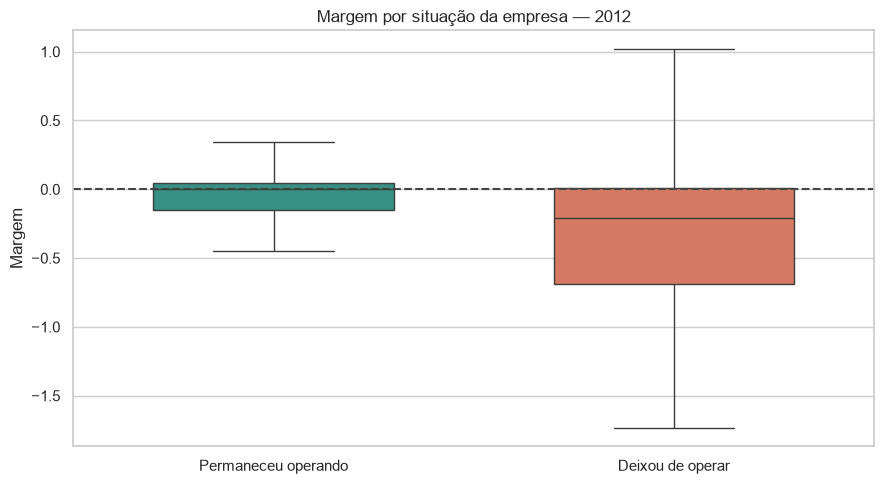

In [108]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=base_2012,
    x="situacao",
    y="margem",
    hue="situacao",
    palette=cores_situacao,
    legend=False,
    showfliers=False,
    width=0.6
)

plt.axhline(
    y=0,
    color="#444444",
    linestyle="--",
    linewidth=1.5
)

plt.title("Margem por situação da empresa — 2012")
plt.xlabel("")
plt.ylabel("Margem")
plt.tight_layout()
plt.show()
# Comparação da distribuição da "margem" entre empresas que permaneceram operando e empresas que deixaram de operar em 2012.

Neste boxplot, comparamos a distribuição da margem entre as empresas que permaneceram operando e as que deixaram de operar.

Observa-se que as empresas que permaneceram operando apresentam maior concentração de valores de margem próximos a zero, enquanto, entre as empresas que deixaram de operar, observa-se maior concentração de valores negativos.

Esse pode ser um indicativo de que essa preditora será importante nos modelos

**BOXPLOT DAS VENDAS POR COLABORADOR POR SITUAÇÃO DA EMPRESA — 2012**

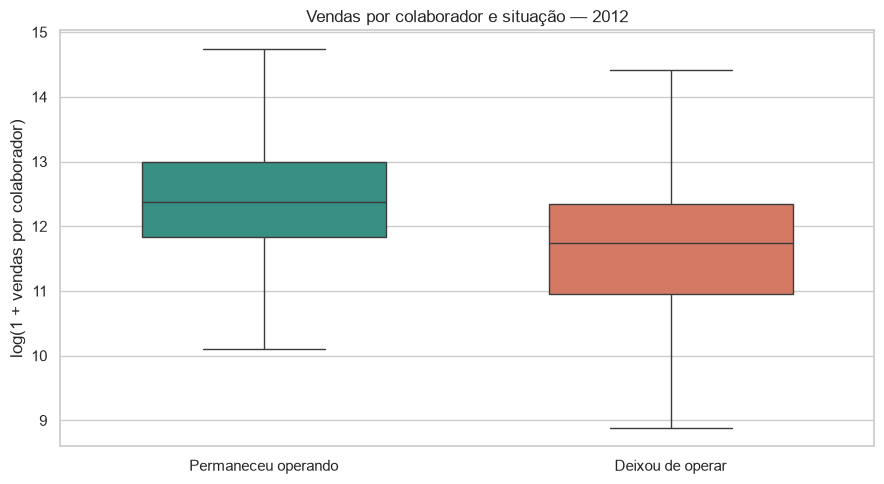

In [109]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=base_2012,
    x="situacao",
    y="venda_por_colaborador_log",
    hue="situacao",
    palette=cores_situacao,
    legend=False,
    showfliers=False,
    width=0.6
)

plt.title("Vendas por colaborador e situação — 2012")
plt.xlabel("")
plt.ylabel("log(1 + vendas por colaborador)")
plt.tight_layout()
plt.show()
# Comparação da distribuição de "venda_por_colaborador_log" entre empresas que permaneceram operando e empresas que deixaram de operar em 2012.

O boxplot mostra distribuições relativamente próximas entre os dois grupos, mas observa-se maior concentração de valores de venda por colaborador entre as empresas que permaneceram operando.

**TAXA DE ENCERRAMENTO POR PORTE**

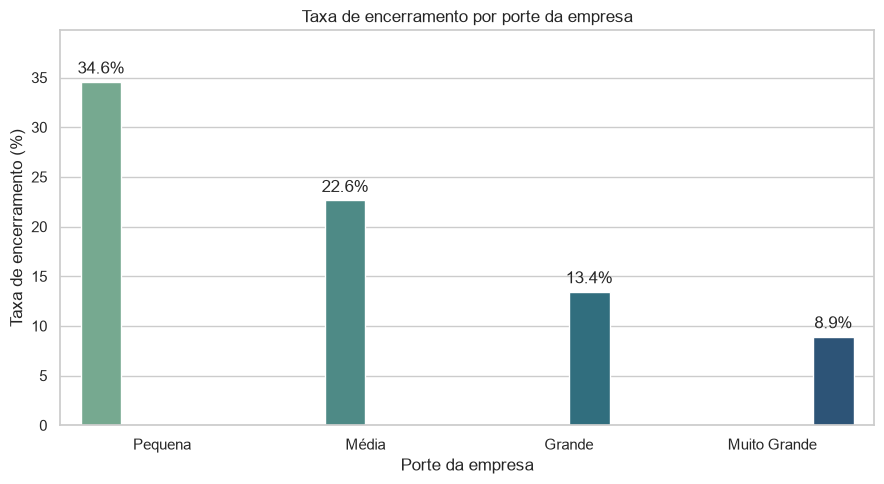

In [110]:
taxa = (
    base_2012
    .groupby("porte_empresa", observed=True)["deixou_de_operar"]
    .mean()
    .mul(100)
    .reset_index(name="taxa_encerramento")
)
# Calcula a taxa de encerramento em cada porte

ordem_porte = [
    "Pequena",
    "Média",
    "Grande",
    "Muito Grande"
]

plt.figure(figsize=(9, 5))

ax = sns.barplot(
    data=taxa,
    x="porte_empresa",
    y="taxa_encerramento",
    hue="porte_empresa",
    order=ordem_porte,
    hue_order=ordem_porte,
    palette="crest",
    legend=False,
    edgecolor="white"
)
# Ordem desejada das categorias

for barra in ax.patches:
    altura = barra.get_height()

    if not np.isnan(altura):
        ax.text(
            barra.get_x() + barra.get_width() / 2,
            altura + 0.5,
            f"{altura:.1f}%",
            ha="center",
            va="bottom"
        )
# Insere o percentual acima de cada barra

plt.ylabel("Taxa de encerramento (%)")
plt.xlabel("Porte da empresa")
plt.title("Taxa de encerramento por porte da empresa")
plt.ylim(0, taxa["taxa_encerramento"].max() * 1.15)
plt.tight_layout()
plt.show()

O gráfico apresenta a taxa de empresas que deixaram de operar em cada categoria de porte. As empresas pequenas apresentaram uma taxa de encerramento de 34,6%, enquanto as empresas muito grandes registraram apenas 8,9%. Observa-se que o porte da empresa possui forte relação com sua continuidade operacional, sendo uma variável potencialmente relevante para o modelo de predição.

**CORRELAÇÃO ENTRE AS NOVAS PREDITORAS**

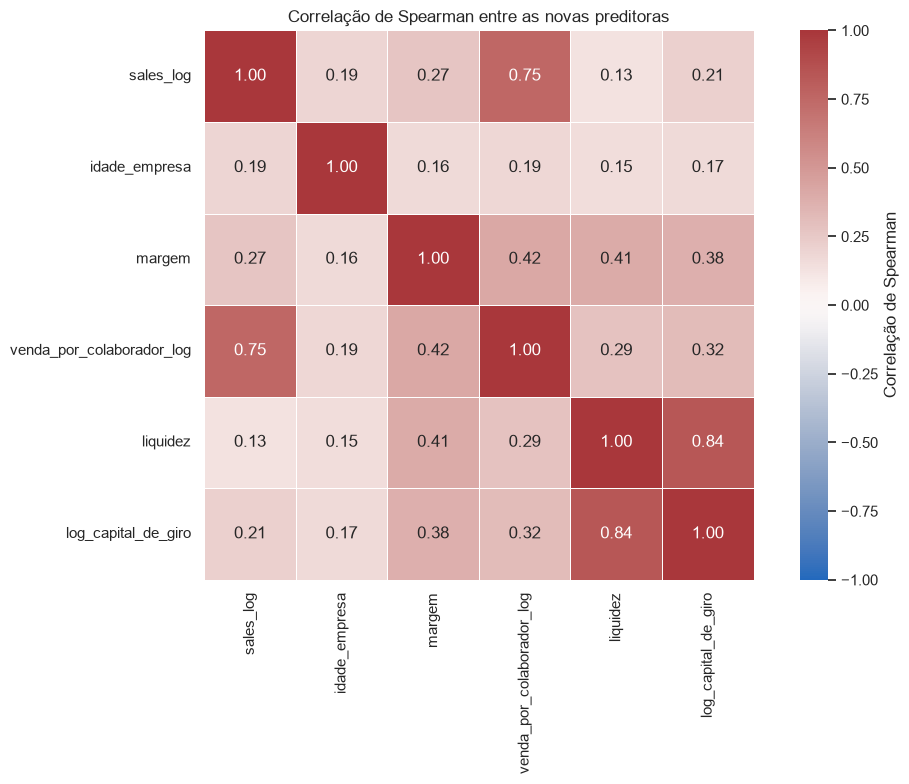

In [111]:
dados_correlacao = base_2012[
    [
        "sales_log",
        "idade_empresa",
        "margem",
        "venda_por_colaborador_log",
        "liquidez",
        "log_capital_de_giro"
    ]
].copy()
# Seleciona as novas preditoras numéricas

correlacoes = dados_correlacao.corr(
    method="spearman"
)
# Calcula a correlação de Spearman


plt.figure(figsize=(11, 8))
sns.heatmap(
    correlacoes,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    cbar_kws={
        "label": "Correlação de Spearman"
    }
)

plt.title(
    "Correlação de Spearman entre as novas preditoras"
)

plt.tight_layout()
plt.show()
# Visualização da matriz de correlação em um heatmap.

Utilizamos um heatmap para analisar a correlação entre as novas preditoras e identificar possíveis relações de alta correlação entre as variáveis, que poderiam indicar redundância na utilização conjunta nos modelos preditivos.

**LIMPEZA FINAL E CRIAÇÃO DA BASE PARA OS MODELOS**

Nesta etapa retiramos identificadores, datas, informações futuras e versões intermediárias das variáveis. Também removemos "female" e "foreign", pois são versões numéricas redundantes de "gender" e "origin", e retiramos "inoffice_days" depois de criar sua versão categórica "faixa_inoffice_days".

Nas rodadas iniciais dos modelos, a análise da importância das preditoras também indicou possíveis redundâncias entre variáveis que representam a mesma informação em escalas diferentes ou como componentes e totais. Por isso, mantemos "sales_log" e retiramos "sales"; mantemos "venda_por_colaborador_log" e retiramos "venda_por_colaborador"; e retiramos o agregado "fixed_assets", preservando seus componentes "tang_assets" e "intang_assets". 

**SELEÇÃO DAS COLUNAS ENTREGUES AOS MODELOS**

A célula seguinte cria "base_2012_final" somente com a resposta e as preditoras disponíveis no momento da previsão.

Nesta etapa também retiramos "nace_main" e "ind", mantendo apenas "ind2" como classificação setorial.
O capital de giro original também é retirado, mantendo-se "log_capital_de_giro", que preserva o sinal e reduz a influência de valores extremos.


In [112]:
colunas_excluir_finais = [
    "comp_id",
    "exit_year",
    "exit_date",
    "sales_x_mais_2",
    "founded_year",
    "founded_date",
    "founded_year_date",
    "founded_year_consolidado",
    "birth_year",
    "female",
    "foreign",
    "inoffice_days",
    "begin",
    "end",
    "year",
    "situacao",
    "faixa_idade",
    "nace_main",
    "ind",
    "capital_de_giro",
    "sales",
    "venda_por_colaborador",
    "fixed_assets"
]
# Colunas excluídas da base final antes da entrega aos modelos.

base_2012_final = (
    base_2012
    .drop(
        columns=colunas_excluir_finais,
        errors="ignore"
    )
    .reset_index(drop=True)
    .copy()
)

In [113]:
base_2012_final.info()
# Conferência da estrutura da base final entregue aos modelos.

<class 'pandas.DataFrame'>
RangeIndex: 21714 entries, 0 to 21713
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   amort                      21674 non-null  float64 
 1   curr_assets                21704 non-null  float64 
 2   curr_liab                  21704 non-null  float64 
 3   extra_exp                  21714 non-null  float64 
 4   extra_inc                  21714 non-null  float64 
 5   extra_profit_loss          21714 non-null  float64 
 6   inc_bef_tax                21714 non-null  float64 
 7   intang_assets              21704 non-null  float64 
 8   inventories                21704 non-null  float64 
 9   liq_assets                 21704 non-null  float64 
 10  material_exp               21674 non-null  float64 
 11  personnel_exp              21674 non-null  float64 
 12  profit_loss_year           21704 non-null  float64 
 13  share_eq                   21704 non-null 

In [114]:
quantidade_antes_remocao = len(base_2012_final)
registros_com_ausencia = base_2012_final.isna().any(axis=1).sum()

base_2012_final = (
    base_2012_final
    .dropna()
    .reset_index(drop=True)
    .copy()
)

quantidade_depois_remocao = len(base_2012_final)
percentual_removido = (
    registros_com_ausencia
    / quantidade_antes_remocao
    * 100
)

print("Observações antes da remoção:", quantidade_antes_remocao)
print("Observações removidas:", registros_com_ausencia)
print(f"Percentual removido: {percentual_removido:.2f}%")
print("Observações restantes:", quantidade_depois_remocao)
# Verificação e remoção das observações que apresentam valores ausentes na base final.

display(
    base_2012_final["deixou_de_operar"]
    .value_counts()
    .rename("quantidade")
    .to_frame()
    .assign(
        percentual=lambda tabela: (
            tabela["quantidade"]
            / quantidade_depois_remocao
            * 100
        )
    )
)
# Conferência da distribuição da variável resposta após a remoção dos valores ausentes.

Observações antes da remoção: 21714
Observações removidas: 5021
Percentual removido: 23.12%
Observações restantes: 16693


,quantidade,percentual
deixou_de_operar,,
0,13441,80.51878
1,3252,19.48122


**DIMENSÃO DA BASE FINAL**

In [115]:
base_2012_final.shape

(16693, 36)

**ESTRUTURA DA BASE FINAL**

In [116]:
base_2012_final.info()
# Conferência da estrutura da base final entregue aos modelos.

<class 'pandas.DataFrame'>
RangeIndex: 16693 entries, 0 to 16692
Data columns (total 36 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   amort                      16693 non-null  float64 
 1   curr_assets                16693 non-null  float64 
 2   curr_liab                  16693 non-null  float64 
 3   extra_exp                  16693 non-null  float64 
 4   extra_inc                  16693 non-null  float64 
 5   extra_profit_loss          16693 non-null  float64 
 6   inc_bef_tax                16693 non-null  float64 
 7   intang_assets              16693 non-null  float64 
 8   inventories                16693 non-null  float64 
 9   liq_assets                 16693 non-null  float64 
 10  material_exp               16693 non-null  float64 
 11  personnel_exp              16693 non-null  float64 
 12  profit_loss_year           16693 non-null  float64 
 13  share_eq                   16693 non-null 

**VISUALIZAÇÃO DOS VALORES AUSENTES NA BASE FINAL**

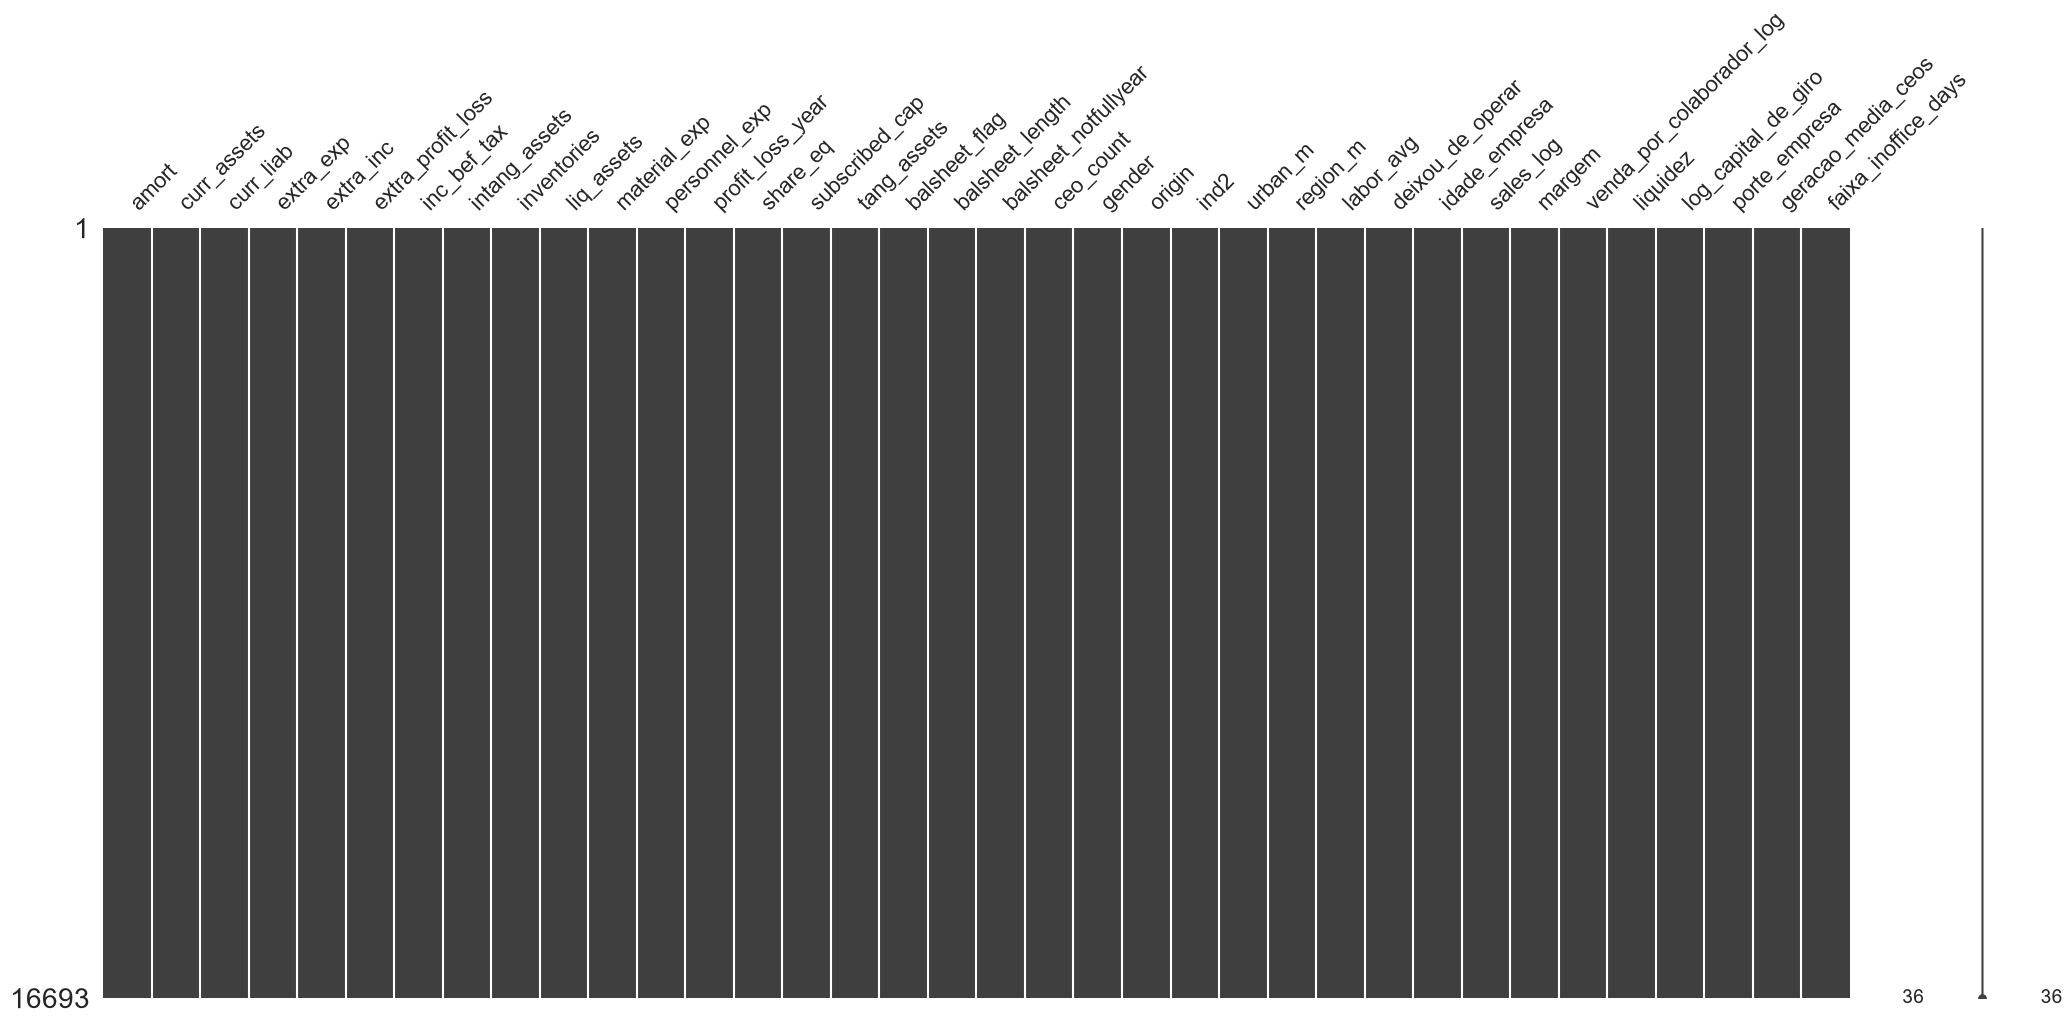

In [117]:
msno.matrix(base_2012_final);
# Verificação da presença de valores ausentes na base final.

**VERIFICAÇÕES FINAIS E VALORES AUSENTES**

Antes da modelagem, confirmamos que a variável resposta está completa, que as variáveis categóricas estão adequadamente classificadas e que identificadores, datas e informações futuras não permanecem na base destinada aos modelos.

A conferência abaixo verifica também a estrutura da base, a ausência de valores ausentes e a disponibilidade das variáveis necessárias para a modelagem.

In [118]:
colunas_proibidas = {
    "comp_id",
    "situacao",
    "exit_year",
    "exit_date",
    "sales_x_mais_2",
    "begin",
    "end",
    "year",
    "birth_year",
    "female",
    "foreign",
    "inoffice_days"
}

colunas_proibidas_presentes = colunas_proibidas.intersection(
    base_2012_final.columns
)
# Verificação da presença de colunas que não devem permanecer na base final.


colunas_indice_presentes = [
    coluna
    for coluna in base_2012_final.columns
    if str(coluna).startswith("Unnamed:")
    or str(coluna).lower() in {"index", "level_0"}
]
# Verificação da presença de colunas que podem representar índices ou identificadores.


if colunas_proibidas_presentes:
    raise ValueError(
        "Colunas indevidas presentes na base final: "
        f"{sorted(colunas_proibidas_presentes)}"
    )

if colunas_indice_presentes:
    raise ValueError(
        f"Colunas de índice presentes: {colunas_indice_presentes}"
    )

if base_2012_final.isna().any().any():
    colunas_ainda_ausentes = (
        base_2012_final.isna().sum()
        .loc[lambda serie: serie > 0]
        .to_dict()
    )
    raise ValueError(
        "A base final ainda possui valores ausentes: "
        f"{colunas_ainda_ausentes}"
    )

if base_2012_final["deixou_de_operar"].isna().any():
    raise ValueError("A variável resposta ainda possui valores ausentes.")
# Verificação da ausência de valores ausentes na variável resposta.

if base_2012_final["geracao_media_ceos"].isna().any():
    raise ValueError("A faixa etária dos CEOs ainda possui valores ausentes.")
# Verificação da ausência de valores ausentes na variável categórica de geração dos CEOs.

print("Dimensões finais:", base_2012_final.shape)
print("Linhas totalmente duplicadas:", base_2012_final.duplicated().sum())
print("Resposta ausente:", base_2012_final["deixou_de_operar"].isna().sum())
print("Total de valores ausentes:", base_2012_final.isna().sum().sum())
print(
    "Geração média dos CEOs não informada:",
    base_2012_final["geracao_media_ceos"]
    .eq("Não informado")
    .sum()
)

display(
    base_2012_final.isna().mean()
    .mul(100)
    .sort_values(ascending=False)
    .loc[lambda serie: serie > 0]
    .rename("percentual_missing")
)


Dimensões finais: (16693, 36)
Linhas totalmente duplicadas: 0
Resposta ausente: 0
Total de valores ausentes: 0
Geração média dos CEOs não informada: 2387


Series([], Name: percentual_missing, dtype: float64)

**EXPORTAÇÃO DA BASE FINAL**

In [119]:
caminho_exportacao = "base_final.csv"

base_2012_final.to_csv(
    caminho_exportacao,
    index=False,
    encoding="utf-8"
)
# Exportação da base final para arquivo CSV.